<a href="https://colab.research.google.com/github/baronpeters/ChBE-440-Process-Control-and-Dynamics/blob/main/PI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.kill(os.getpid(), 9)

**Analysis of tank level control problem with two inlet streams**

q1 = load input

q2 = manipulated input

h = controlled state variable



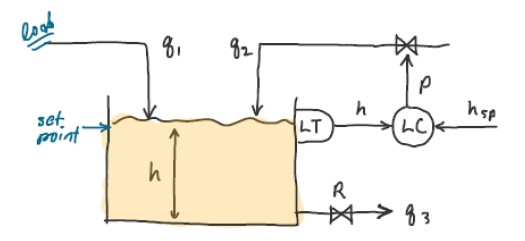

**Process model:**

A dh/dt = q1 + q2 - h/R

Deviation variables: dx = x - xss

Laplace transforms: dx(t) -> X(s)

A s H = Q1 + Q2 - H/R

Now let's get a process transfer function:

In [ ]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

# declare all variables in process model in s-domain
s, H, Q1, Q2, R, A = sympy.symbols('s H Q1 Q2 R A')

# LHS = RHS as 1st and 2nd arguments
eqn = sympy.Eq(A*s*H, Q1 + Q2 - H/R)

# solve for H
soln = sympy.solve(eqn, H)

# extract H(s) from list of solutions (just one - it was linear)
print(f"H = {soln[0]}")

# define process transfer function
Gp = sympy.symbols('Gp')
Gp = sympy.simplify(soln[0] / (Q1 + Q2))
print(f"Gp(s) = {Gp}")

# the controller acts on q2
Gc, Hsp = sympy.symbols('Gc Hsp')
eqn = sympy.Eq(H, soln[0].subs({Q2: Gc*(Hsp-H)}))

# solve for the closed loop transfer function
soln = sympy.solve(eqn, H)
print(f"H = {soln[0]}")

H = R*(Q1 + Q2)/(A*R*s + 1)
Gp(s) = R/(A*R*s + 1)
H = R*(Gc*Hsp + Q1)/(A*R*s + Gc*R + 1)


**Now we have to decide**

(1) What is the control algorithm?  

(2) What changes/disturbances are of interest?

**1.  Proportional (P) control with a unit step setpoint change**

In [ ]:
kc, dhsp = sympy.symbols('kc dhsp')
H = soln[0].subs({Gc: kc, Q1: 0, Hsp: dhsp/s})
print(f"H(s) = {H}")

H(s) = R*dhsp*kc/(s*(A*R*s + R*kc + 1))


Closed-loop transfer function

In [ ]:
GCL = sympy.simplify(H * s/dhsp)
print(f"GCL(s) = {GCL}")

# there are three parameters in GCL: A, R, and kc
# put into 1plus form to reduce parameter space to two

numerator_GCL = sympy.fraction(GCL)[0]
denominator_GCL = sympy.fraction(GCL)[1]
constant_term_denom = denominator_GCL.subs({s: 0})

if constant_term_denom != 0:
    kCL_ = sympy.simplify(numerator_GCL / constant_term_denom)
    tCL_ = sympy.simplify((denominator_GCL / constant_term_denom - 1)/s)
    print(f"kCL = {kCL_}")
    print(f"tCL = {tCL_}")
    print(f"GCL(s) = kCL/(tCL s + 1)")
else:
    print("Cannot write in 1plus form: constant term in the denominator is zero.")

kCL, tCL = sympy.symbols('kCL tCL')
GCL = kCL / (tCL * s + 1)


GCL(s) = R*kc/(A*R*s + R*kc + 1)
kCL = R*kc/(R*kc + 1)
tCL = A*R/(R*kc + 1)
GCL(s) = kCL/(tCL s + 1)


**Invert the Laplace Transform**

In [ ]:
t, y = sympy.symbols('t y')
H_s = GCL / s
y = sympy.inverse_laplace_transform(H_s, s, t)
print(f"dh(t)/dhsp = {y}")

dh(t)/dhsp = kCL*(Heaviside(t) - exp(-t/tCL)*Heaviside(t))


**Plot solutions**

As a function of t/AR at different values of kcR.  This way the time axis reflects the fixed apparatus, and the different curves show how the controller parameter kcR changes the setpoint response.  

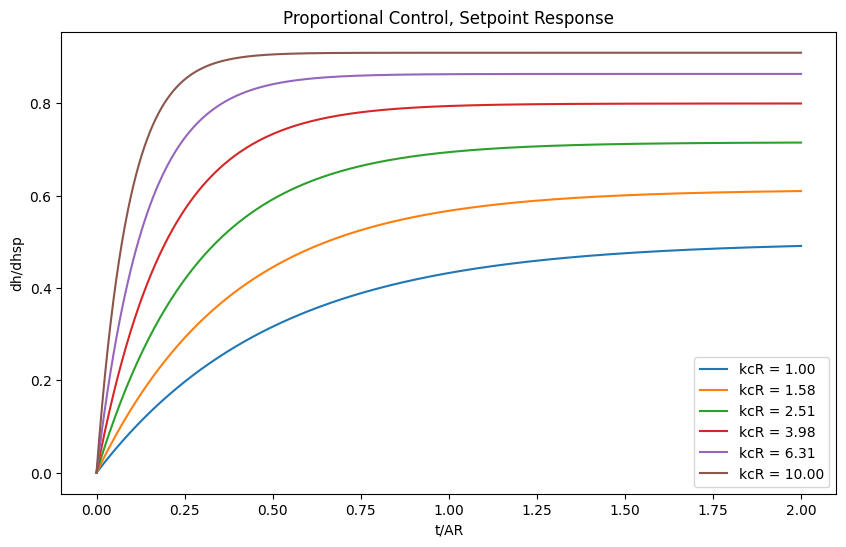

In [21]:
# y = kCL * (1 - exp(-t / tCL))
# y = (kcR/(1+kcR))*(1-exp(-(t/AR)*(1+kcR)))

import sympy
import numpy as np
import matplotlib.pyplot as plt

t, kcR = sympy.symbols('t kcR')
def y(t, kcR):
  return float ((kcR/(1+kcR))*(1 - sympy.exp(-t*(1+kcR))))

# Generate an array of kcR values
kcR_values = np.logspace(0.0, 1.0, num=6, base=10.0)

# Generate an array of time values
t_values = np.linspace(0, 2, 500) # From 0 to 5 normalized time units

# Plot the solutions for each kcR value
plt.figure(figsize=(10, 6))

for kcR in kcR_values:
    y_output = [y(t, kcR) for t in t_values]
    plt.plot(t_values, y_output, label=f'kcR = {kcR:.2f}')

plt.title('Proportional Control, Setpoint Response')
plt.xlabel('t/AR')
plt.ylabel('dh/dhsp')
plt.legend()
plt.show()

 ====================

**1.  PI control with a unit step setpoint change**

Reuse work up through Gp(s)

In [22]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

# declare all variables in process model in s-domain
s, H, R, A = sympy.symbols('s H R A')

# define process and closed-loop transfer functions
Gp, Gc, GCL, Hsp, tI, kc, dhsp= sympy.symbols('Gp Gc GCL Hsp tI kc dhsp')
Gp = R/(A*R*s + 1)
GCL = Gc*Gp/(1+Gc*Gp)
GCL = GCL.subs({Gc: kc*(1+1/(tI*s))})

print(f"GCL(s) = {GCL}")

GCL(s) = R*kc*(1 + 1/(s*tI))/((A*R*s + 1)*(R*kc*(1 + 1/(s*tI))/(A*R*s + 1) + 1))


Inverse laplace transform of GCL(s)/s to get dh(t)/dhsp
gives a messy function and sympy does a lousy job at simplifying it.  

I recommend changing variables from A*R*s to "sar".  Then after transformation, you will already have t' = t/AR built into the result.  Makes simplification easier.  

In [23]:
sar, tIar, GCL, H, y, kcR, AR = sympy.symbols('sar tIar GCL H y kcR AR')
# sar = A*R*s
# tIar = tI/(A*R)
GCL = kcR*(1 + 1/(sar*tIar))/((sar + 1)*(kcR*(1 + 1/(sar*tIar))/(sar + 1) + 1))
H = AR*GCL/sar
y = sympy.inverse_laplace_transform(H, sar, t)
y = sympy.simplify(y)
print(f"dh(s)/hsp = {y}")

dh(s)/hsp = AR*(sqrt((4*kcR - tIar*(kcR**2 + 2*kcR + 1))/tIar)*exp(t*(kcR + 1)) - (sqrt((4*kcR - tIar*(kcR**2 + 2*kcR + 1))/tIar)*cos(t*sqrt(-kcR**2 - 2*kcR + 4*kcR/tIar - 1)/2) + (1 - kcR)*sin(t*sqrt(-kcR**2 - 2*kcR + 4*kcR/tIar - 1)/2))*exp(t*(kcR + 1)/2))*exp(-t*(kcR + 1))*Heaviside(t)/sqrt((4*kcR - tIar*(kcR**2 + 2*kcR + 1))/tIar)


In [24]:
def phi(kcR, tIar):
  return sqrt((4*kcR - tIar*(kcR**2 + 2*kcR + 1))/tIar)

def psi(kcR, tIar):
  return sqrt(-kcR**2 - 2*kcR + 4*kcR/tIar - 1)/2

def y(t, kcR, tIar, AR):
  return AR*(1 - exp(-t*(kcR + 1)/2)*(cos(t*psi(kcR, tIar)) + ((1-kcR)/phi(kcR, tIar))*sin(t*psi(kcR, tIar))))

work in progress - stay tuned.  